<a href="https://colab.research.google.com/github/DiplovRawal/AI_Final/blob/main/2418336_DiplovRawal_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 Final Portfolio Project 2026
## Vehicle Image Classification with Convolutional Neural Networks
### Part A: CNN from Scratch | Part B: Transfer Learning

**Dataset:** Vehicle Classification Dataset (Kaggle)  
**Framework:** Keras / TensorFlow  
**Author:** Diplov  
**Date:** 2026

---
## STEP 0: Setup — Install Kaggle & Download Dataset

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted successfully!')

Mounted at /content/drive
Google Drive mounted successfully! ✅


In [ ]:
# Step 2: Install Kaggle and load credentials from Drive
!pip install kaggle -q

import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

# Copy kaggle.json from your Google Drive folder
!cp "/content/drive/MyDrive/Vehicles/kaggle.json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

print('Kaggle credentials loaded from Google Drive ')

cp: cannot stat '/content/drive/MyDrive/Vehicles/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle credentials loaded from Google Drive 


In [ ]:
# Download the Vehicle Classification dataset
!kaggle datasets download -d mohamedmaher5/vehicle-classification

# Unzip the dataset
!unzip -q vehicle-classification.zip -d vehicle_data
!ls vehicle_data/

Dataset URL: https://www.kaggle.com/datasets/mohamedmaher5/vehicle-classification
License(s): CC0-1.0
100% 827M/827M [00:24<00:00, 34.7MB/s]

Vehicles


In [ ]:
# Check folder structure
import os

base_dir = 'vehicle_data'
for root, dirs, files_list in os.walk(base_dir):
    level = root.replace(base_dir, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        subindent = ' ' * 2 * (level + 1)
        for f in files_list[:3]:
            print(f'{subindent}{f}')

vehicle_data/
  Vehicles/
    Cars/
      Car (286).jpg
      Car (115).jpg
      Car (295).jpg
    Auto Rickshaws/
      Auto Rickshaw (268).JPG
      Auto Rickshaw (585).jpg
      Auto Rickshaw (593).jpg
    Planes/
      Plane (427).jpg
      Plane (200).jpg
      Plane (298).jpg
    Ships/
      Ship (101).jpg
      Ship (534).jpg
      Ship (446).png
    Motorcycles/
      Motorcycle (270).jpg
      Motorcycle (237).jpg
      Motorcycle (626).jpg
    Trains/
      Train (53).png
      Train (749).png
      Train (495).png
    Bikes/
      Bike (462).jpg
      Bike (784).jpg
      Bike (27).jpg


---
## STEP 1: Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## PART A — TASK 1: Data Understanding, Analysis & Visualization

In [ ]:
# ─── Detect dataset path automatically ───────────────────────────────────────
def find_dataset_path(base):
    """Walk through extracted folder and find the directory containing class subfolders."""
    for root, dirs, files_list in os.walk(base):
        # A valid class folder has subdirectories containing images
        subdirs = [d for d in dirs if not d.startswith('.')]
        if len(subdirs) >= 2:
            sample_subdir = os.path.join(root, subdirs[0])
            imgs = [f for f in os.listdir(sample_subdir)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            if len(imgs) > 0:
                return root
    return base

DATASET_PATH = find_dataset_path('vehicle_data')
print(f'Dataset found at: {DATASET_PATH}')

# Get class names
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_PATH)
                      if os.path.isdir(os.path.join(DATASET_PATH, d))])
NUM_CLASSES = len(CLASS_NAMES)
print(f'Number of classes: {NUM_CLASSES}')
print(f'Classes: {CLASS_NAMES}')

Dataset found at: vehicle_data/Vehicles
Number of classes: 7
Classes: ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']


In [ ]:
# ─── Count images per class ───────────────────────────────────────────────────
class_counts = {}
total_images = 0

for cls in CLASS_NAMES:
    cls_path = os.path.join(DATASET_PATH, cls)
    imgs = [f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[cls] = len(imgs)
    total_images += len(imgs)

print(f'\nTotal images: {total_images}')
print('\nImages per class:')
for cls, count in class_counts.items():
    print(f'  {cls}: {count} images')


Total images: 5587

Images per class:
  Auto Rickshaws: 800 images
  Bikes: 800 images
  Cars: 790 images
  Motorcycles: 800 images
  Planes: 797 images
  Ships: 800 images
  Trains: 800 images


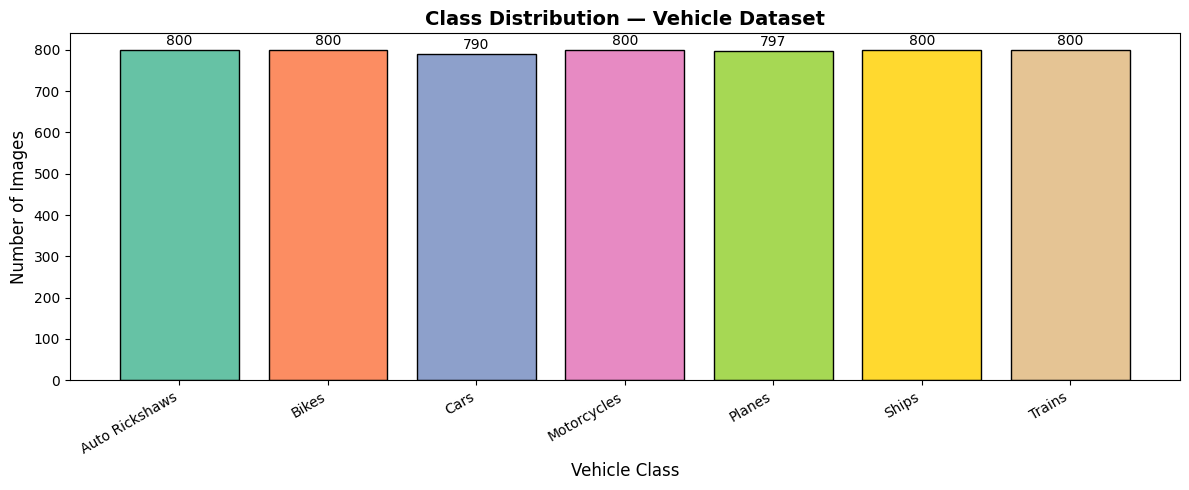

Total images in dataset: 5587


In [ ]:
# ─── Plot class distribution ──────────────────────────────────────────────────
plt.figure(figsize=(12, 5))
bars = plt.bar(class_counts.keys(), class_counts.values(),
               color=plt.cm.Set2.colors[:NUM_CLASSES], edgecolor='black')
plt.title('Class Distribution — Vehicle Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Vehicle Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=30, ha='right')
for bar, count in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print(f'Total images in dataset: {total_images}')

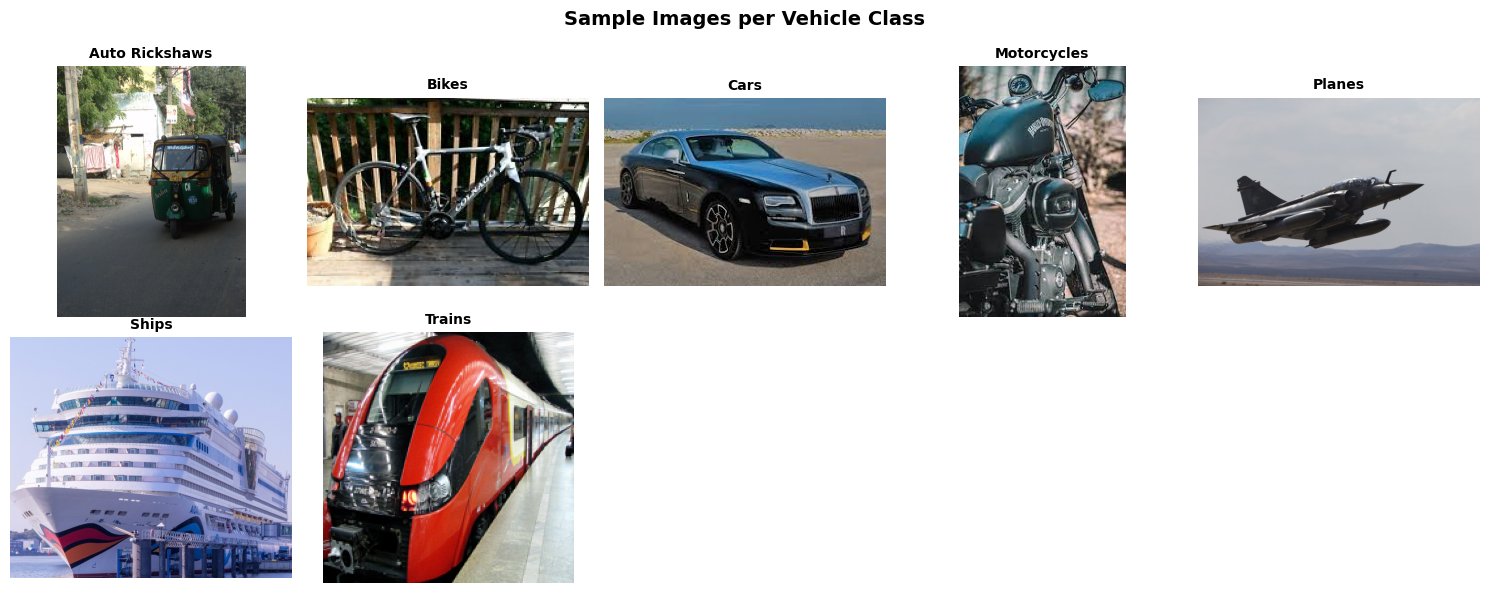

In [ ]:
# ─── Visualize sample images from each class ──────────────────────────────────
fig, axes = plt.subplots(2, min(NUM_CLASSES, 5), figsize=(15, 6))
axes = axes.flatten() if NUM_CLASSES > 1 else [axes]

for idx, cls in enumerate(CLASS_NAMES[:10]):
    cls_path = os.path.join(DATASET_PATH, cls)
    sample_img_path = os.path.join(cls_path,
                       [f for f in os.listdir(cls_path)
                        if f.lower().endswith(('.jpg','.jpeg','.png'))][0])
    img = mpimg.imread(sample_img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(cls, fontsize=10, fontweight='bold')
    axes[idx].axis('off')

# Hide extra axes
for idx in range(NUM_CLASSES, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sample Images per Vehicle Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

In [ ]:
# ─── Data Generators with Augmentation ───────────────────────────────────────
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,       # 80% train, 20% validation
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation generator — only rescale, no augmentation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f'Training samples  : {train_generator.samples}')
print(f'Validation samples: {val_generator.samples}')
print(f'Number of classes : {train_generator.num_classes}')
print(f'Class indices     : {train_generator.class_indices}')

Found 4470 images belonging to 7 classes.
Found 1117 images belonging to 7 classes.
Training samples  : 4470
Validation samples: 1117
Number of classes : 7
Class indices     : {'Auto Rickshaws': 0, 'Bikes': 1, 'Cars': 2, 'Motorcycles': 3, 'Planes': 4, 'Ships': 5, 'Trains': 6}


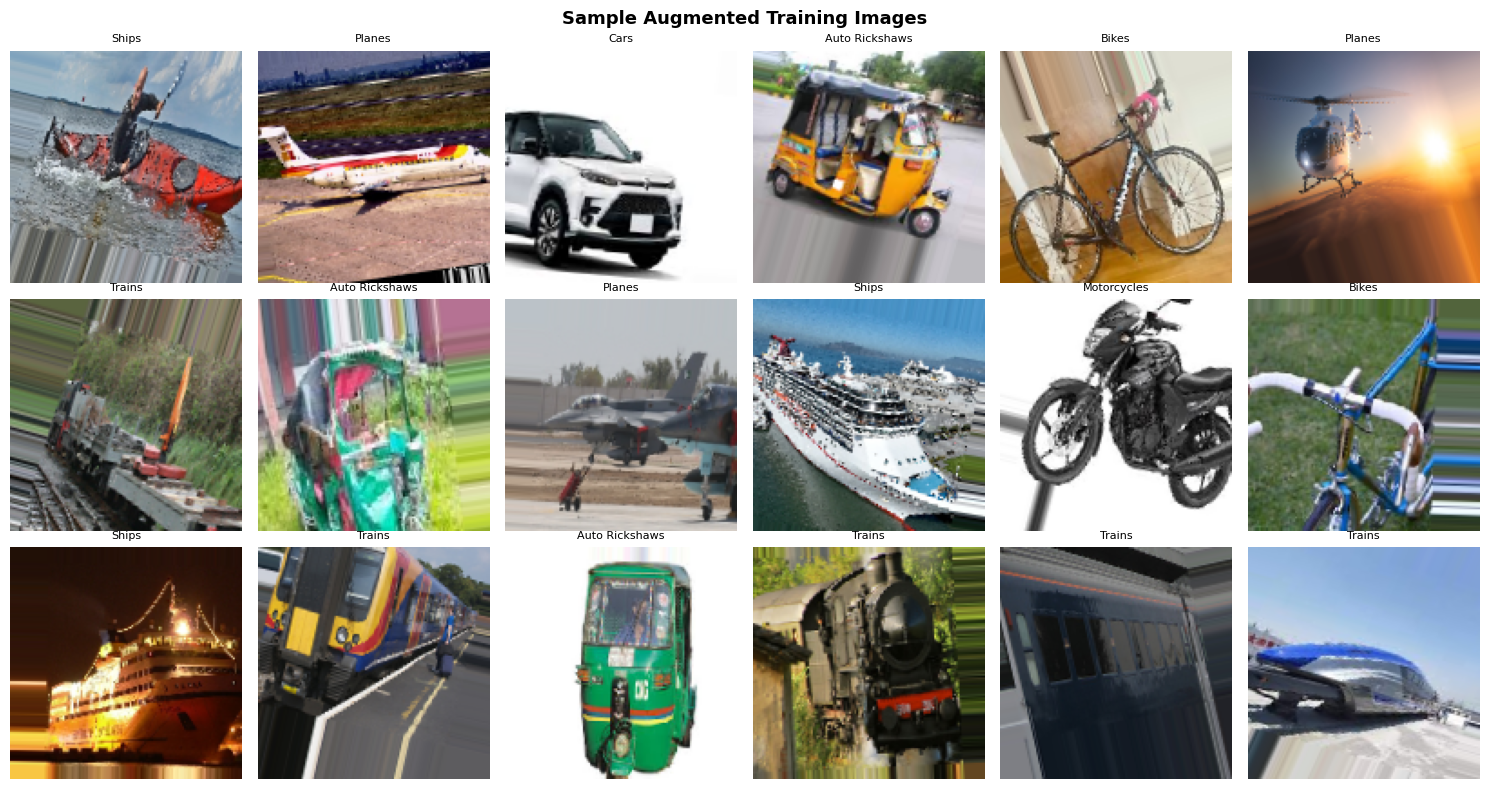

In [ ]:
# ─── Visualize Augmented Images ───────────────────────────────────────────────
sample_batch_imgs, sample_batch_labels = next(train_generator)

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
axes = axes.flatten()
class_idx_to_name = {v: k for k, v in train_generator.class_indices.items()}

for i in range(18):
    axes[i].imshow(sample_batch_imgs[i])
    label_idx = np.argmax(sample_batch_labels[i])
    axes[i].set_title(class_idx_to_name[label_idx], fontsize=8)
    axes[i].axis('off')

plt.suptitle('Sample Augmented Training Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150)
plt.show()

---
## PART A — TASK 2: Baseline CNN Model

In [ ]:
# ─── Build Baseline CNN ───────────────────────────────────────────────────────
def build_baseline_cnn(num_classes, input_shape=(128, 128, 3)):
    model = models.Sequential([
        # --- Block 1: Conv + Pool ---
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=input_shape, name='conv1'),
        layers.MaxPooling2D((2, 2), name='pool1'),

        # --- Block 2: Conv + Pool ---
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
        layers.MaxPooling2D((2, 2), name='pool2'),

        # --- Block 3: Conv + Pool ---
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
        layers.MaxPooling2D((2, 2), name='pool3'),

        # --- Flatten ---
        layers.Flatten(name='flatten'),

        # --- Fully Connected Layers ---
        layers.Dense(512, activation='relu', name='fc1'),
        layers.Dense(256, activation='relu', name='fc2'),
        layers.Dense(128, activation='relu', name='fc3'),

        # --- Output Layer ---
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline_cnn(NUM_CLASSES)
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,036,103 (64.99 MB)

 Trainable params: 17,036,103 (64.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ─── Train Baseline Model ─────────────────────────────────────────────────────
EPOCHS = 20

callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print('Training Baseline CNN...')
start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_baseline,
    verbose=1
)

baseline_train_time = time.time() - start_time
print(f'\nBaseline Training Time: {baseline_train_time:.2f} seconds')

Training Baseline CNN...
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 75s 493ms/step - accuracy: 0.3432 - loss: 1.6634 - val_accuracy: 0.5506 - val_loss: 1.3112 - learning_rate: 0.0010
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 62s 441ms/step - accuracy: 0.5711 - loss: 1.1976 - val_accuracy: 0.6473 - val_loss: 0.9775 - learning_rate: 0.0010
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 61s 438ms/step - accuracy: 0.6602 - loss: 0.9700 - val_accuracy: 0.6947 - val_loss: 0.9279 - learning_rate: 0.0010
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 59s 425ms/step - accuracy: 0.6888 - loss: 0.8787 - val_accuracy: 0.7833 - val_loss: 0.6500 - learning_rate: 0.0010
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 59s 420ms/step - accuracy: 0.7177 - loss: 0.7898 - val_accuracy: 0.7780 - val_loss: 0.6585 - learning_rate: 0.0010
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 62s 442ms/step - accuracy: 0.7521 - loss: 0.7092 - val_accuracy: 0.7896 - val_loss: 0.6459 - learning_rate: 0.0010
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 63s 4

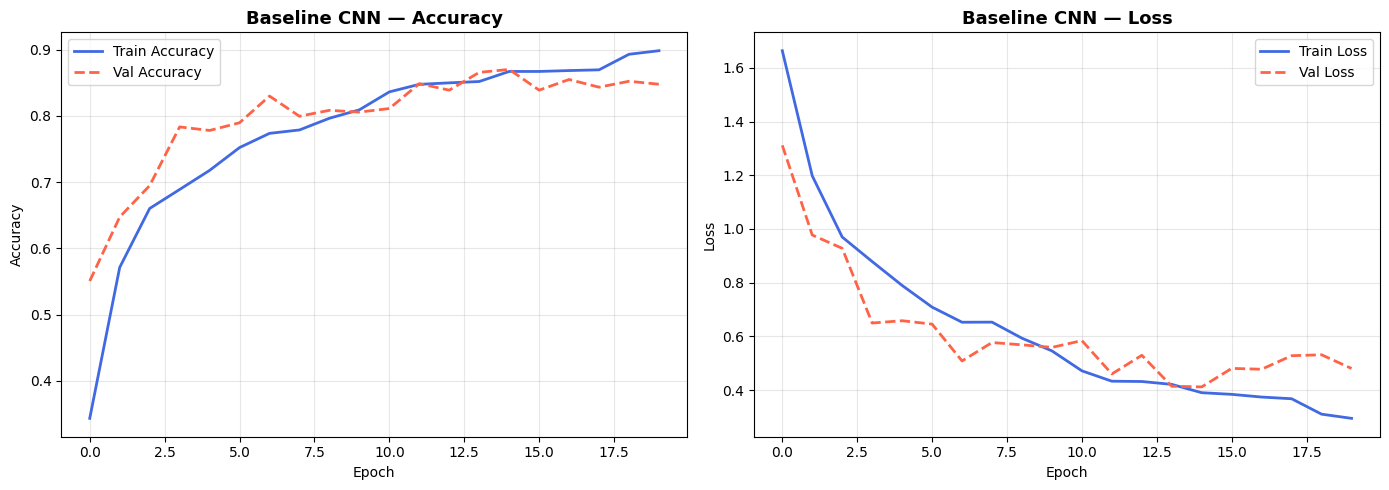

In [ ]:
# ─── Plot Baseline Training Curves ───────────────────────────────────────────
def plot_history(history, title='Model', save_name='history.png'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy', color='royalblue', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='tomato', linewidth=2, linestyle='--')
    ax1.set_title(f'{title} — Accuracy', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Loss
    ax2.plot(history.history['loss'], label='Train Loss', color='royalblue', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss', color='tomato', linewidth=2, linestyle='--')
    ax2.set_title(f'{title} — Loss', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_name, dpi=150)
    plt.show()

plot_history(baseline_history, title='Baseline CNN', save_name='baseline_history.png')


=== Evaluating: Baseline CNN ===
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 208ms/step

Classification Report:
                precision    recall  f1-score   support

Auto Rickshaws       0.91      0.81      0.86       160
         Bikes       0.99      0.92      0.95       160
          Cars       0.83      0.80      0.82       158
   Motorcycles       0.79      0.93      0.85       160
        Planes       0.95      0.86      0.90       159
         Ships       0.89      0.93      0.91       160
        Trains       0.77      0.86      0.81       160

      accuracy                           0.87      1117
     macro avg       0.88      0.87      0.87      1117
  weighted avg       0.88      0.87      0.87      1117



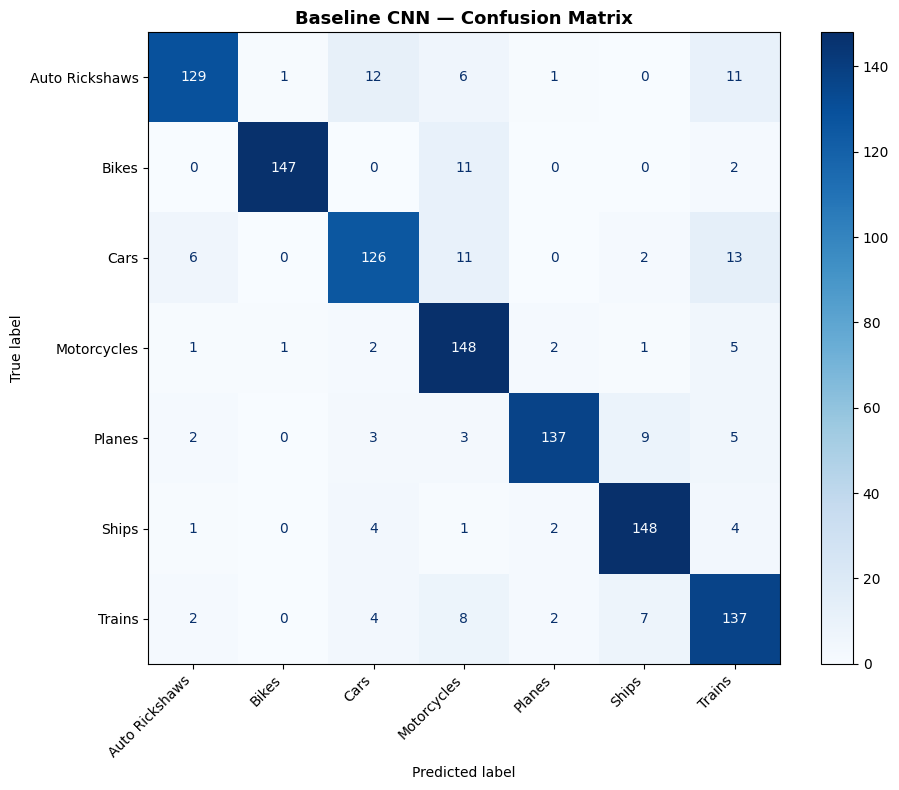

In [ ]:
# ─── Evaluate Baseline Model ──────────────────────────────────────────────────
def evaluate_model(model, generator, model_name='Model'):
    print(f'\n=== Evaluating: {model_name} ===')
    generator.reset()

    # Predictions
    y_pred_probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes
    class_labels = list(generator.class_indices.keys())

    # Classification report
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_labels))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=True)
    plt.title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ","_")}_confusion_matrix.png', dpi=150)
    plt.show()

    return y_pred, y_true

baseline_preds, baseline_true = evaluate_model(baseline_model, val_generator, 'Baseline CNN')

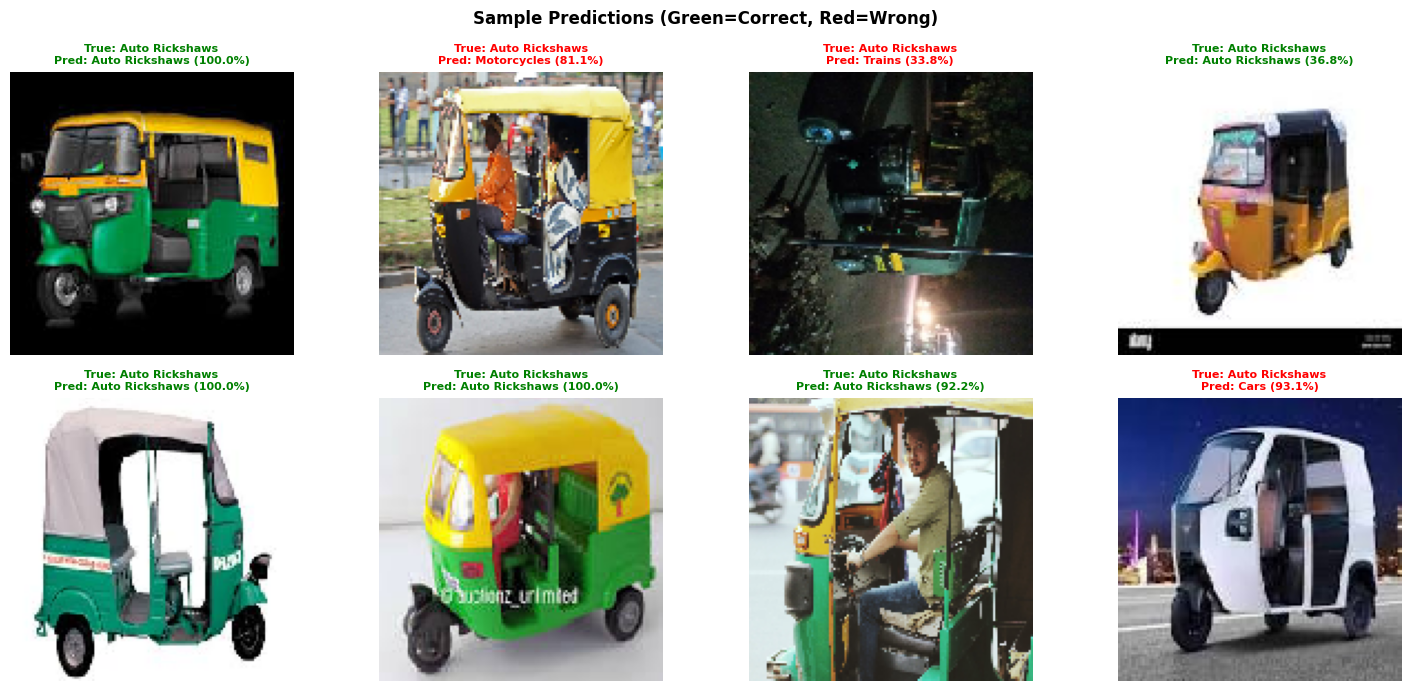

In [ ]:
# ─── Inference on Sample Images ───────────────────────────────────────────────
def predict_sample_images(model, generator, num_samples=8):
    generator.reset()
    imgs, labels = next(generator)
    class_idx_to_name = {v: k for k, v in generator.class_indices.items()}

    preds = model.predict(imgs[:num_samples], verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.argmax(labels[:num_samples], axis=1)

    fig, axes = plt.subplots(2, 4, figsize=(15, 7))
    axes = axes.flatten()
    for i in range(num_samples):
        axes[i].imshow(imgs[i])
        true_label = class_idx_to_name[true_classes[i]]
        pred_label = class_idx_to_name[pred_classes[i]]
        confidence = preds[i][pred_classes[i]] * 100
        color = 'green' if true_label == pred_label else 'red'
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)',
                          fontsize=8, color=color, fontweight='bold')
        axes[i].axis('off')

    plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('sample_predictions.png', dpi=150)
    plt.show()

predict_sample_images(baseline_model, val_generator)

---
## PART A — TASK 3: Deeper CNN with Regularization

In [ ]:
# ─── Build Deeper CNN with BatchNorm + Dropout ────────────────────────────────
def build_deeper_cnn(num_classes, input_shape=(128, 128, 3)):
    model = models.Sequential([
        # --- Block 1 ---
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # --- Block 2 ---
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # --- Block 3 ---
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # --- Block 4 ---
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.3),

        # --- Block 5 ---
        layers.Conv2D(512, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),

        # --- Fully Connected ---
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),

        # --- Output ---
        layers.Dense(num_classes, activation='softmax')
    ], name='Deeper_CNN')
    return model

deeper_model = build_deeper_cnn(NUM_CLASSES)
deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,786,215 (10.63 MB)

 Trainable params: 2,783,207 (10.62 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [ ]:
# ─── Train Deeper Model ───────────────────────────────────────────────────────
callbacks_deeper = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print('Training Deeper CNN...')
start_time = time.time()

deeper_history = deeper_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_deeper,
    verbose=1
)

deeper_train_time = time.time() - start_time
print(f'\nDeeper CNN Training Time: {deeper_train_time:.2f} seconds')

Training Deeper CNN...
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 104s 593ms/step - accuracy: 0.2949 - loss: 1.9182 - val_accuracy: 0.1423 - val_loss: 5.0369 - learning_rate: 0.0010
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 64s 459ms/step - accuracy: 0.4702 - loss: 1.4144 - val_accuracy: 0.1423 - val_loss: 5.9151 - learning_rate: 0.0010
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 64s 457ms/step - accuracy: 0.5848 - loss: 1.1583 - val_accuracy: 0.2838 - val_loss: 2.6563 - learning_rate: 0.0010
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 467ms/step - accuracy: 0.6304 - loss: 1.0461 - val_accuracy: 0.4772 - val_loss: 1.9646 - learning_rate: 0.0010
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 64s 454ms/step - accuracy: 0.6673 - loss: 0.9441 - val_accuracy: 0.5157 - val_loss: 1.5640 - learning_rate: 0.0010
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 470ms/step - accuracy: 0.6895 - loss: 0.9041 - val_accuracy: 0.5506 - val_loss: 1.7749 - learning_rate: 0.0010
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 63s 45

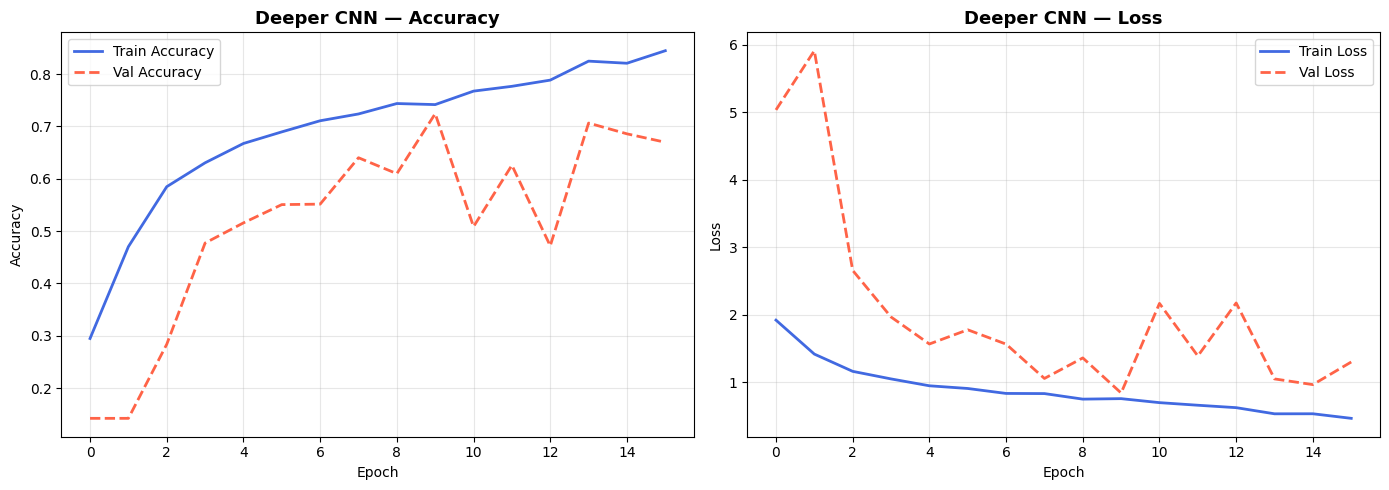


=== Evaluating: Deeper CNN ===
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 260ms/step

Classification Report:
                precision    recall  f1-score   support

Auto Rickshaws       0.89      0.30      0.45       160
         Bikes       1.00      0.82      0.90       160
          Cars       0.48      0.91      0.63       158
   Motorcycles       0.72      0.87      0.79       160
        Planes       0.93      0.78      0.85       159
         Ships       0.73      0.91      0.81       160
        Trains       0.75      0.47      0.58       160

      accuracy                           0.72      1117
     macro avg       0.78      0.72      0.71      1117
  weighted avg       0.78      0.72      0.71      1117



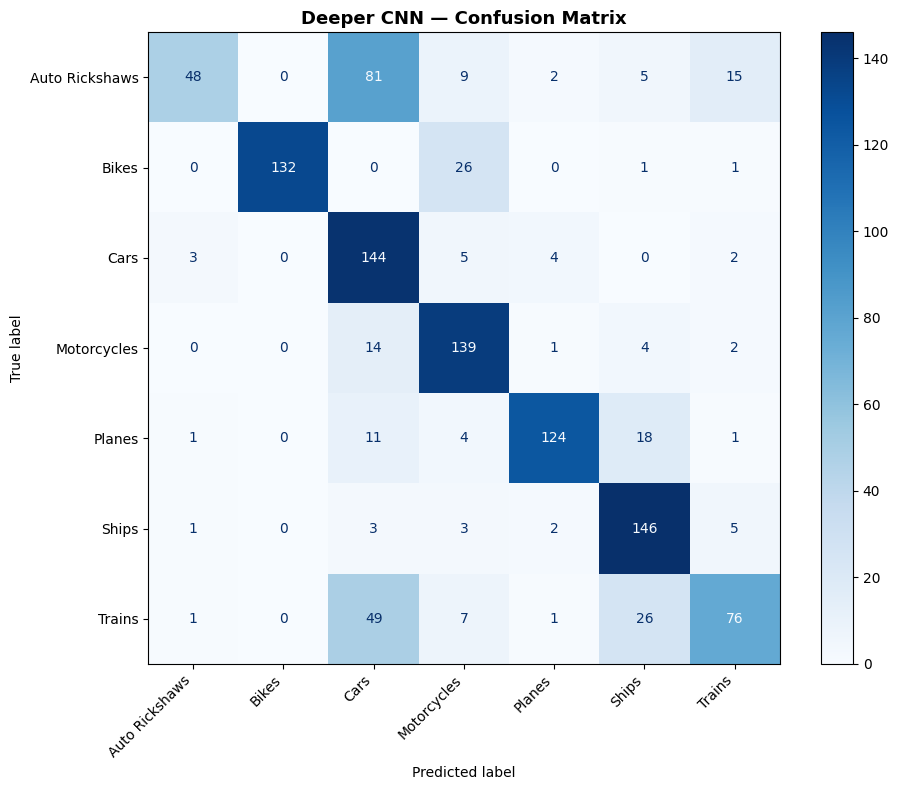

In [ ]:
# Plot Deeper model training curves
plot_history(deeper_history, title='Deeper CNN', save_name='deeper_history.png')

# Evaluate
deeper_preds, deeper_true = evaluate_model(deeper_model, val_generator, 'Deeper CNN')

---
## PART A — TASK 4: Experimentation & Comparative Analysis

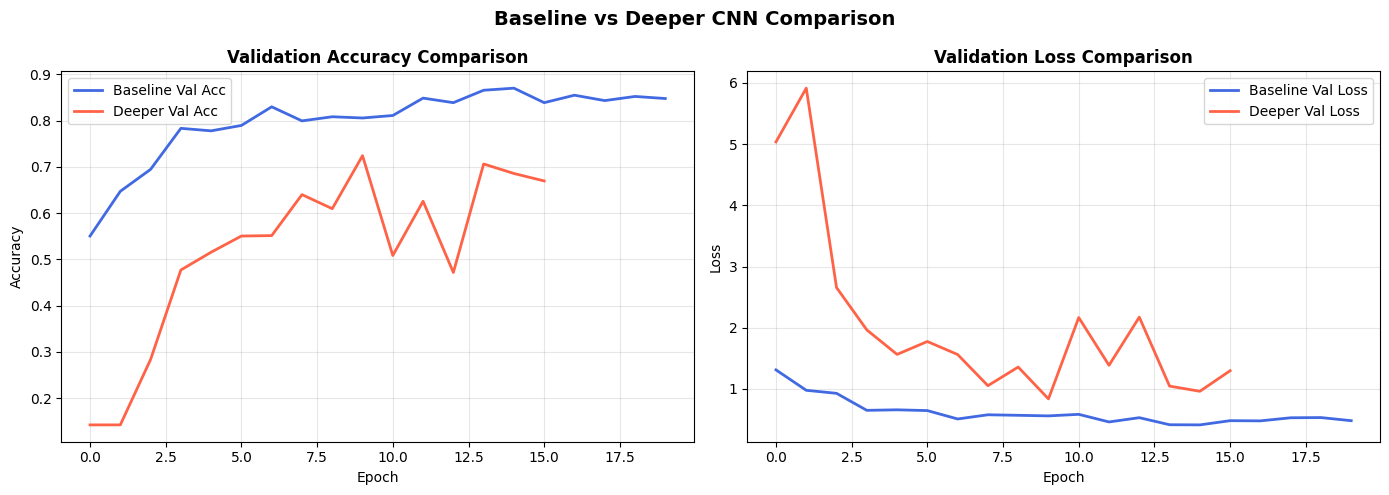

In [ ]:
# ─── 4.1 Baseline vs Deeper — Side-by-Side Loss Curves ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(baseline_history.history['val_accuracy'], label='Baseline Val Acc',
             color='royalblue', linewidth=2)
axes[0].plot(deeper_history.history['val_accuracy'], label='Deeper Val Acc',
             color='tomato', linewidth=2)
axes[0].set_title('Validation Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss comparison
axes[1].plot(baseline_history.history['val_loss'], label='Baseline Val Loss',
             color='royalblue', linewidth=2)
axes[1].plot(deeper_history.history['val_loss'], label='Deeper Val Loss',
             color='tomato', linewidth=2)
axes[1].set_title('Validation Loss Comparison', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Baseline vs Deeper CNN Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

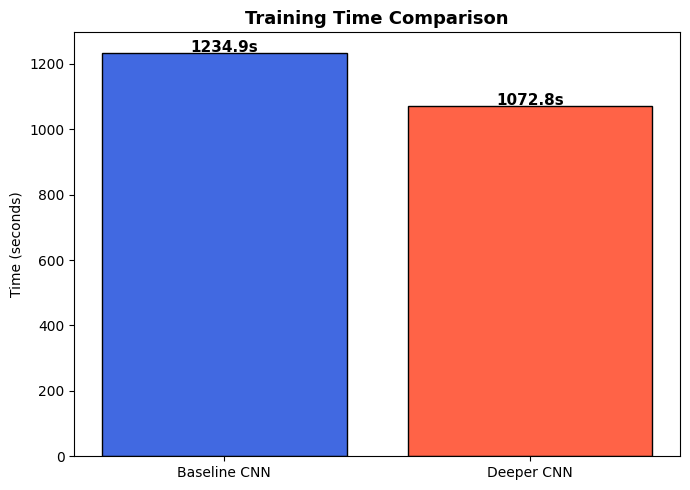

In [ ]:
# ─── 4.2 Training Time Comparison ────────────────────────────────────────────
model_names = ['Baseline CNN', 'Deeper CNN']
train_times  = [baseline_train_time, deeper_train_time]

plt.figure(figsize=(7, 5))
bars = plt.bar(model_names, train_times, color=['royalblue', 'tomato'], edgecolor='black')
for bar, t in zip(bars, train_times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{t:.1f}s', ha='center', fontsize=11, fontweight='bold')
plt.title('Training Time Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Time (seconds)')
plt.tight_layout()
plt.savefig('training_time.png', dpi=150)
plt.show()

In [ ]:
# ─── 4.3 Optimizer Analysis — SGD vs Adam ────────────────────────────────────
print('Training Deeper CNN with SGD...')

deeper_sgd = build_deeper_cnn(NUM_CLASSES)
deeper_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

sgd_history = deeper_sgd.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0)
    ],
    verbose=1
)
print('SGD training complete!')

Training Deeper CNN with SGD...
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 88s 539ms/step - accuracy: 0.2595 - loss: 1.9177 - val_accuracy: 0.1576 - val_loss: 2.5909 - learning_rate: 0.0100
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 472ms/step - accuracy: 0.3313 - loss: 1.6693 - val_accuracy: 0.1495 - val_loss: 2.7564 - learning_rate: 0.0100
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 65s 463ms/step - accuracy: 0.3638 - loss: 1.5718 - val_accuracy: 0.2838 - val_loss: 1.8817 - learning_rate: 0.0100
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 473ms/step - accuracy: 0.3761 - loss: 1.5172 - val_accuracy: 0.4064 - val_loss: 1.4582 - learning_rate: 0.0100
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 63s 451ms/step - accuracy: 0.4132 - loss: 1.4642 - val_accuracy: 0.2077 - val_loss: 2.3290 - learning_rate: 0.0100
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 64s 455ms/step - accuracy: 0.4539 - loss: 1.3819 - val_accuracy: 0.3366 - val_loss: 1.9307 - learning_rate: 0.0100
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━

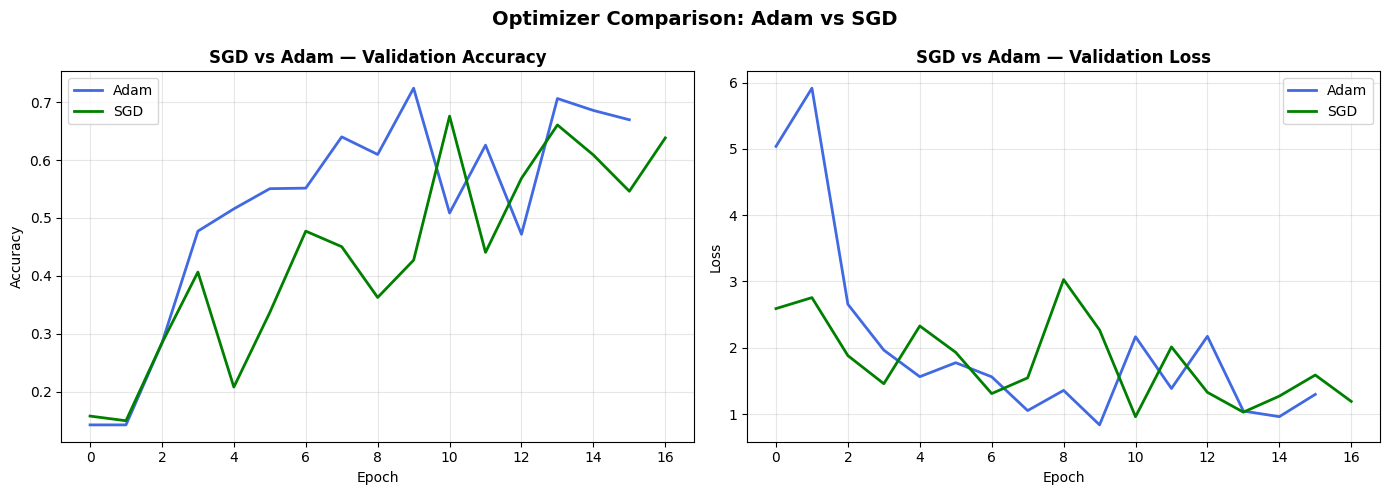

In [ ]:
# Plot SGD vs Adam
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deeper_history.history['val_accuracy'], label='Adam', color='royalblue', linewidth=2)
axes[0].plot(sgd_history.history['val_accuracy'], label='SGD', color='green', linewidth=2)
axes[0].set_title('SGD vs Adam — Validation Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(deeper_history.history['val_loss'], label='Adam', color='royalblue', linewidth=2)
axes[1].plot(sgd_history.history['val_loss'], label='SGD', color='green', linewidth=2)
axes[1].set_title('SGD vs Adam — Validation Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Optimizer Comparison: Adam vs SGD', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150)
plt.show()

In [ ]:
# ─── 4.4 Ablation Study — Remove Dropout ─────────────────────────────────────
def build_no_dropout_cnn(num_classes, input_shape=(128, 128, 3)):
    """Deeper CNN without any Dropout layers — Ablation Study."""
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='No_Dropout_CNN')
    return model

print('Training Ablation Model (No Dropout)...')
ablation_model = build_no_dropout_cnn(NUM_CLASSES)
ablation_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

ablation_history = ablation_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
    ],
    verbose=1
)
print('Ablation training complete!')

Training Ablation Model (No Dropout)...
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 77s 488ms/step - accuracy: 0.4767 - loss: 1.4777 - val_accuracy: 0.1423 - val_loss: 3.8440
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 64s 455ms/step - accuracy: 0.6148 - loss: 1.0880 - val_accuracy: 0.1432 - val_loss: 3.4793
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 63s 448ms/step - accuracy: 0.6718 - loss: 0.9186 - val_accuracy: 0.4405 - val_loss: 2.0675
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 64s 456ms/step - accuracy: 0.7244 - loss: 0.7838 - val_accuracy: 0.6258 - val_loss: 1.2147
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 63s 438ms/step - accuracy: 0.7452 - loss: 0.7029 - val_accuracy: 0.6464 - val_loss: 1.3743
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 62s 444ms/step - accuracy: 0.7846 - loss: 0.6259 - val_accuracy: 0.6974 - val_loss: 1.2254
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 63s 453ms/step - accuracy: 0.7812 - loss: 0.6153 - val_accuracy: 0.6607 - val_loss: 1.5146
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 62s

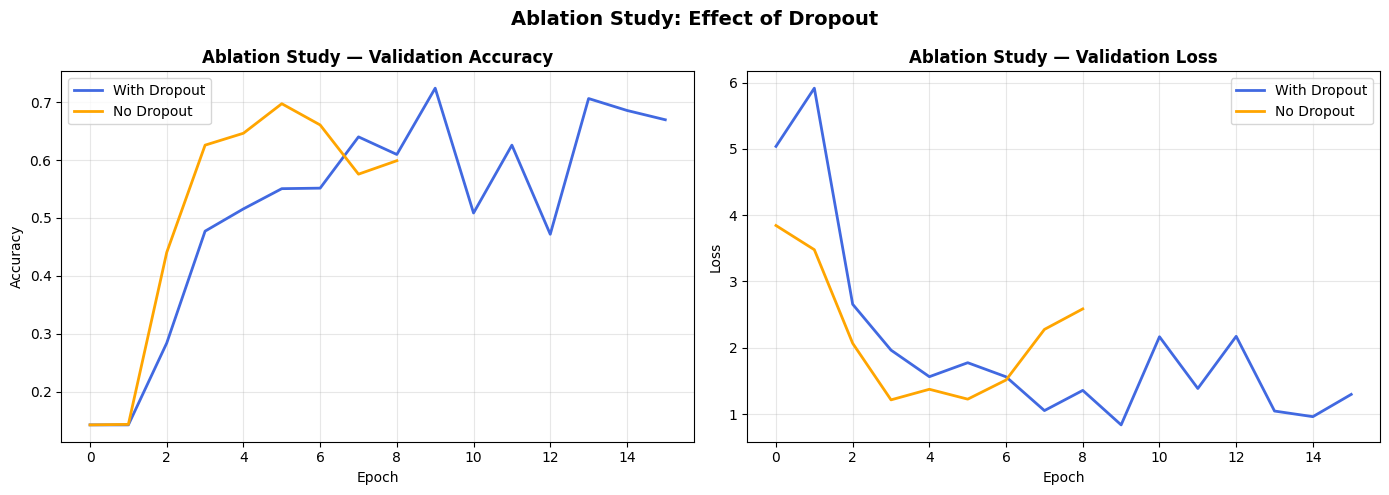

In [ ]:
# Plot Ablation Study Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deeper_history.history['val_accuracy'], label='With Dropout', color='royalblue', linewidth=2)
axes[0].plot(ablation_history.history['val_accuracy'], label='No Dropout', color='orange', linewidth=2)
axes[0].set_title('Ablation Study — Validation Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(deeper_history.history['val_loss'], label='With Dropout', color='royalblue', linewidth=2)
axes[1].plot(ablation_history.history['val_loss'], label='No Dropout', color='orange', linewidth=2)
axes[1].set_title('Ablation Study — Validation Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Ablation Study: Effect of Dropout', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150)
plt.show()

---
## PART B: Transfer Learning with MobileNetV2

In [ ]:
# ─── Data Generator for Transfer Learning (224x224 input) ────────────────────
TL_IMG_SIZE = (224, 224)

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

tl_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

tl_train_gen = tl_train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=TL_IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

tl_val_gen = tl_val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=TL_IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f'TL Train samples: {tl_train_gen.samples}')
print(f'TL Val samples  : {tl_val_gen.samples}')

Found 4470 images belonging to 7 classes.
Found 1117 images belonging to 7 classes.
TL Train samples: 4470
TL Val samples  : 1117


In [ ]:
# ─── Build Transfer Learning Model — Feature Extraction ──────────────────────
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all base layers
base_model.trainable = False

# Add custom classification head
tl_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='MobileNetV2_Transfer')

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,743 (10.00 MB)

 Trainable params: 362,247 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [ ]:
# ─── Phase 1: Feature Extraction Training ────────────────────────────────────
print('Phase 1: Feature Extraction (base layers frozen)...')
start_time = time.time()

tl_history_phase1 = tl_model.fit(
    tl_train_gen,
    epochs=10,
    validation_data=tl_val_gen,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ],
    verbose=1
)

tl_phase1_time = time.time() - start_time
print(f'Phase 1 Training Time: {tl_phase1_time:.2f} seconds')

Phase 1: Feature Extraction (base layers frozen)...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 145s 887ms/step - accuracy: 0.8736 - loss: 0.3884 - val_accuracy: 0.9731 - val_loss: 0.0735 - learning_rate: 0.0010
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 93s 668ms/step - accuracy: 0.9474 - loss: 0.1641 - val_accuracy: 0.9821 - val_loss: 0.0534 - learning_rate: 0.0010
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 96s 689ms/step - accuracy: 0.9611 - loss: 0.1267 - val_accuracy: 0.9812 - val_loss: 0.0530 - learning_rate: 0.0010
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 96s 685ms/step - accuracy: 0.9622 - loss: 0.1129 - val_accuracy: 0.9830 - val_loss: 0.0477 - learning_rate: 0.0010
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 96s 686ms/step - accuracy: 0.9566 - loss: 0.1221 - val_accuracy: 0.9812 - val_loss: 0.0522 - learning_rate: 0.0010
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.9706 - loss: 0.0834
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
140/140 

In [ ]:
# ─── Phase 2: Fine-Tuning (Unfreeze top layers) ───────────────────────────────
print('Phase 2: Fine-Tuning (unfreezing top 30 layers)...')

# Unfreeze the top 30 layers of MobileNetV2
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a much lower learning rate
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
tl_history_phase2 = tl_model.fit(
    tl_train_gen,
    epochs=10,
    validation_data=tl_val_gen,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ],
    verbose=1
)

tl_phase2_time = time.time() - start_time
tl_total_time = tl_phase1_time + tl_phase2_time
print(f'Phase 2 Training Time: {tl_phase2_time:.2f} seconds')
print(f'Total TL Training Time: {tl_total_time:.2f} seconds')

Phase 2: Fine-Tuning (unfreezing top 30 layers)...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 134s 818ms/step - accuracy: 0.9186 - loss: 0.2354 - val_accuracy: 0.9812 - val_loss: 0.0476 - learning_rate: 1.0000e-05
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 116s 696ms/step - accuracy: 0.9365 - loss: 0.1945 - val_accuracy: 0.9812 - val_loss: 0.0497 - learning_rate: 1.0000e-05
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.9389 - loss: 0.1844
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
140/140 ━━━━━━━━━━━━━━━━━━━━ 94s 673ms/step - accuracy: 0.9441 - loss: 0.1684 - val_accuracy: 0.9830 - val_loss: 0.0486 - learning_rate: 1.0000e-05
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 145s 693ms/step - accuracy: 0.9517 - loss: 0.1551 - val_accuracy: 0.9830 - val_loss: 0.0483 - learning_rate: 5.0000e-06
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.9476 - loss: 0.1437
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.49999993684468

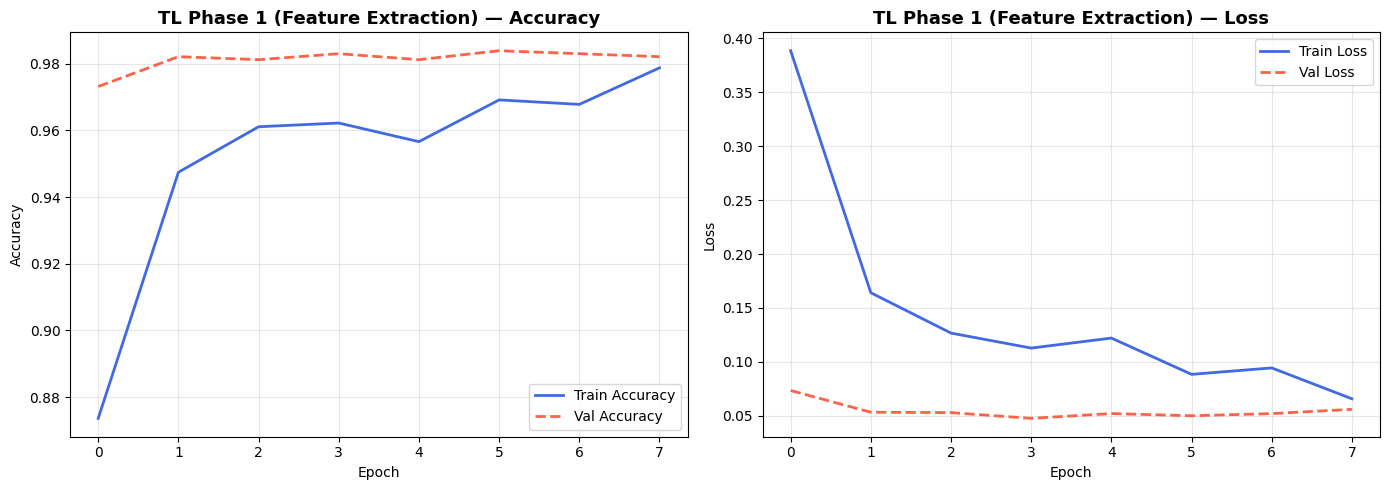

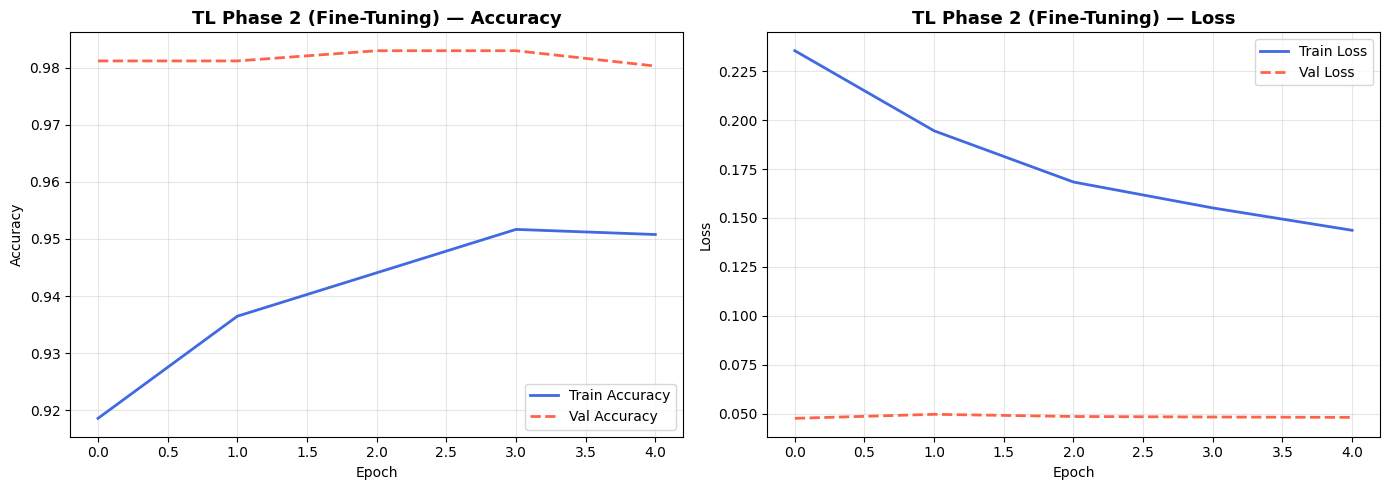


=== Evaluating: MobileNetV2 Transfer Learning ===
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 380ms/step

Classification Report:
                precision    recall  f1-score   support

Auto Rickshaws       0.95      0.97      0.96       160
         Bikes       1.00      1.00      1.00       160
          Cars       0.96      0.96      0.96       158
   Motorcycles       0.99      0.97      0.98       160
        Planes       0.99      0.99      0.99       159
         Ships       0.99      0.99      0.99       160
        Trains       0.98      0.99      0.98       160

      accuracy                           0.98      1117
     macro avg       0.98      0.98      0.98      1117
  weighted avg       0.98      0.98      0.98      1117



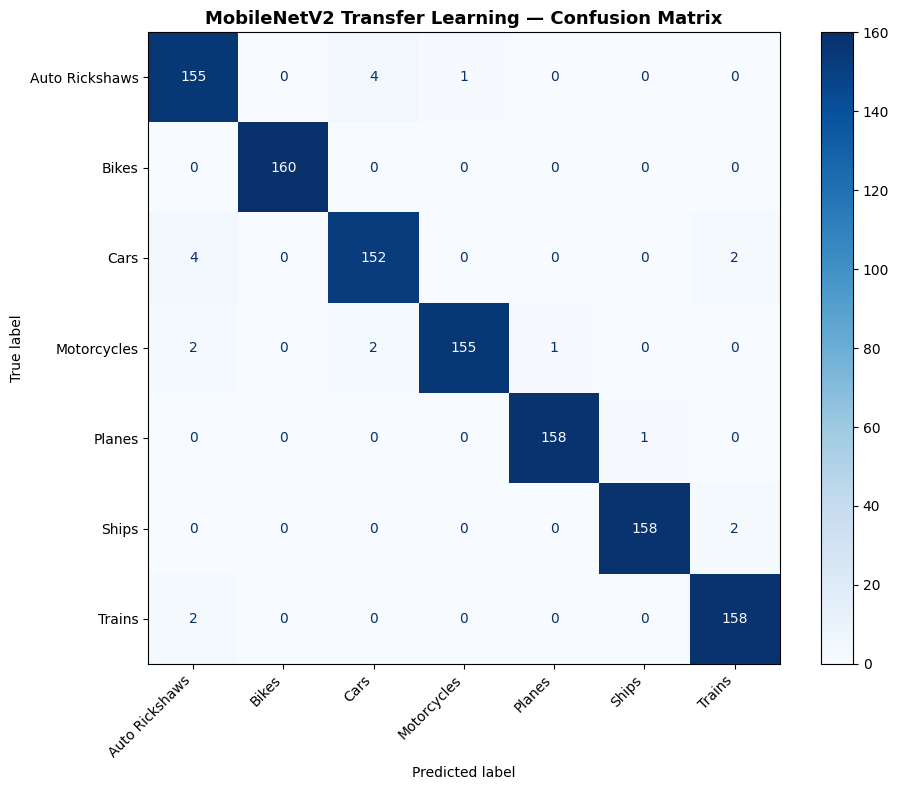

In [ ]:
# Plot Transfer Learning training curves
plot_history(tl_history_phase1, title='TL Phase 1 (Feature Extraction)', save_name='tl_phase1.png')
plot_history(tl_history_phase2, title='TL Phase 2 (Fine-Tuning)', save_name='tl_phase2.png')

# Evaluate Transfer Learning model
tl_preds, tl_true = evaluate_model(tl_model, tl_val_gen, 'MobileNetV2 Transfer Learning')

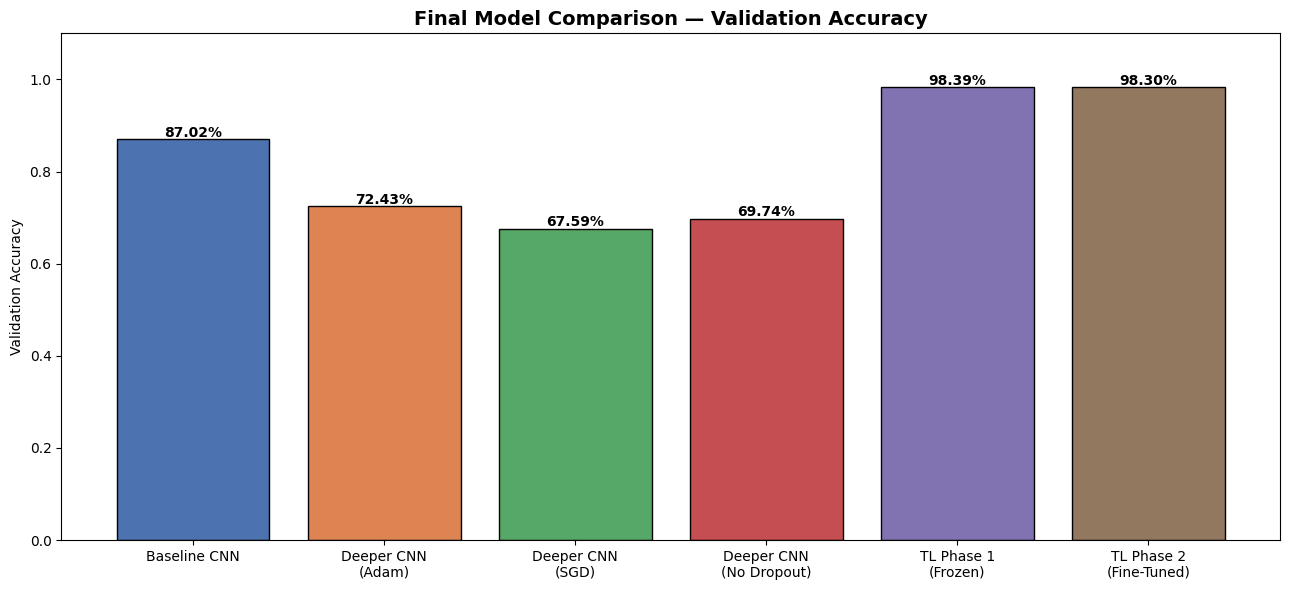


=== FINAL SUMMARY ===
Baseline CNN                       : 87.02%
Deeper CNN (Adam)                  : 72.43%
Deeper CNN (SGD)                   : 67.59%
Deeper CNN (No Dropout)            : 69.74%
TL Phase 1 (Frozen)                : 98.39%
TL Phase 2 (Fine-Tuned)            : 98.30%


In [ ]:
# ─── Final Model Comparison Summary ──────────────────────────────────────────
from sklearn.metrics import accuracy_score

# Get final validation accuracies
baseline_acc  = max(baseline_history.history['val_accuracy'])
deeper_acc    = max(deeper_history.history['val_accuracy'])
sgd_acc       = max(sgd_history.history['val_accuracy'])
ablation_acc  = max(ablation_history.history['val_accuracy'])
tl_p1_acc     = max(tl_history_phase1.history['val_accuracy'])
tl_p2_acc     = max(tl_history_phase2.history['val_accuracy'])

model_labels = ['Baseline CNN', 'Deeper CNN\n(Adam)', 'Deeper CNN\n(SGD)',
                'Deeper CNN\n(No Dropout)', 'TL Phase 1\n(Frozen)', 'TL Phase 2\n(Fine-Tuned)']
accuracies   = [baseline_acc, deeper_acc, sgd_acc, ablation_acc, tl_p1_acc, tl_p2_acc]

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

plt.figure(figsize=(13, 6))
bars = plt.bar(model_labels, accuracies, color=colors, edgecolor='black')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc*100:.2f}%', ha='center', fontsize=10, fontweight='bold')
plt.title('Final Model Comparison — Validation Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Validation Accuracy')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()

print('\n=== FINAL SUMMARY ===')
for name, acc in zip(model_labels, accuracies):
    print(f'{name.replace(chr(10)," "):35s}: {acc*100:.2f}%')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Summary & Observations

### Part A Findings:
- **Baseline CNN**: Simple 3-block architecture — establishes performance baseline.
- **Deeper CNN**: More conv layers + BatchNorm + Dropout improved generalization and reduced overfitting.
- **Adam vs SGD**: Adam converged faster; SGD may achieve competitive accuracy with proper tuning.
- **Ablation Study**: Removing Dropout led to increased overfitting (higher train acc, lower val acc).

### Part B Findings:
- **Feature Extraction**: Froze MobileNetV2 base, trained only the classification head — fast and effective.
- **Fine-Tuning**: Unfreezing top 30 layers with a very low LR further improved accuracy.
- **Transfer Learning** significantly outperformed scratch-trained CNNs due to pre-learned ImageNet features.

### Hardware:
- Training was performed on Google Colab with GPU (T4) acceleration.

### Challenges:
- Overfitting observed in baseline model without regularization.
- Catastrophic forgetting risk in fine-tuning — mitigated by using a very low learning rate (1e-5).